# ロジットモデル

## 導出
### 二項選択モデル

最も単純なケースとして、財の数$J=2$の場合を考える。各財から得られる効用を、平均的な満足度$\beta_j$、価格$p_j$、ランダムな選好ショック$\epsilon_{ij}$で表す：

$$
\begin{aligned}
& U_{i 1}=\beta_1-\alpha p_1+\epsilon_{i 1} \\
& U_{i 2}=\beta_2-\alpha p_2+\epsilon_{i 2}
\end{aligned}
$$

このとき、消費者$i$がとる選択$d_i$は、効用が多い方を選ぶと仮定すれば

$$
d_i= \begin{cases}1 & \text { if } \beta_1-\alpha p_1+\epsilon_{i 1}>\beta_2-\alpha p_2+\epsilon_{i 2} \\
2 & \text { if } \beta_1-\alpha p_1+\epsilon_{i 1} \leq \beta_2-\alpha p_2+\epsilon_{i 2}\end{cases}
$$

となる。したがってその確率は、$j$の効用が高くなる確率

$$
\begin{aligned}
\operatorname{Pr}(d_i=1) & =\operatorname{Pr}\left(\beta_1-\alpha p_1+\epsilon_{i 1}>\beta_2-\alpha p_2+\epsilon_{i 2}\right) \\
& =\operatorname{Pr}\big(\epsilon_{i 1}-\epsilon_{i 2}>-\left(\beta_1-\beta_2-\alpha\left(p_1-p_2\right)\right)\big)
\end{aligned}
$$

となる。

### 二項ロジットモデル

選好ショック$\epsilon_{ij}$が第I種極値分布（ガンベル分布） $P(\epsilon_{i j} \leq x)=F(x)=e^{-e^{-x}}$ に従うと仮定する場合、選好ショックの差分$\epsilon_{i1} - \epsilon_{i2}$ は標準ロジスティック分布 $F(t)=P(X \leq t)=\frac{1}{1+\exp (-t)}$ に従うため、財1の購入確率は次のように表すことができる。

$$
\begin{aligned}
\operatorname{Pr}\left(d_i=1\right)
& =\frac{1}{1+\exp(-\{ \beta_1-\beta_2-\alpha\left(p_1-p_2\right)\})}\\
& =\frac{\exp \left(\beta_1-\beta_2-\alpha\left(p_1-p_2\right)\right)}{1+\exp \left(\beta_1-\beta_2-\alpha\left(p_1-p_2\right)\right)}
\end{aligned}
$$



:::{admonition} ガンベル分布
:class: info

**ガンベル分布（Gumbel distribution）** は極値分布（第I種）の一つで、多数の変数の最大値（または最小値）の分布を近似する際に使われる。ロジットモデルの導出では、選好ショック$\epsilon_{ij}$の分布として仮定される。

累積分布関数：

$$
F(x) = P(X \leq x) = \exp\left(-\exp\left(-\frac{x-\mu}{\beta}\right)\right)
$$

確率密度関数：

$$
f(x) = \frac{1}{\beta}\exp\left(-\frac{x-\mu}{\beta}\right)\exp\left(-\exp\left(-\frac{x-\mu}{\beta}\right)\right)
$$

- $\mu$：位置パラメータ（location parameter）
- $\beta > 0$：尺度パラメータ（scale parameter）
- 期待値：$E[X] = \mu + \gamma\beta$（$\gamma\approx0.5772$：オイラー・マスケローニ定数）
- 分散：$V[X] = \dfrac{\pi^2}{6}\beta^2$

ロジットモデルの導出では標準形（$\mu=0,\ \beta=1$）を使うため、上記の$F(x)$は本文中の$F(x)=e^{-e^{-x}}$の式に一致する。

:::

/tmp/ipykernel_16063/1017810842.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


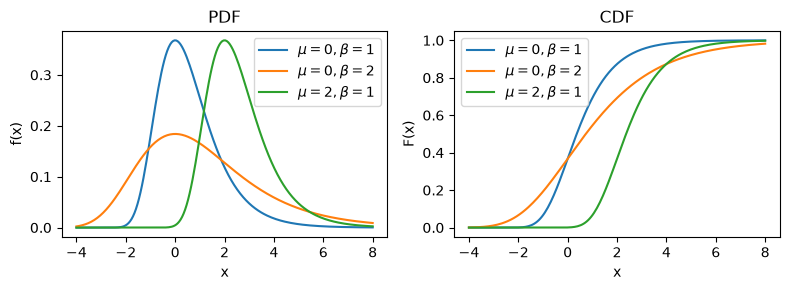

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gumbel_r

x = np.linspace(-4, 8, 200)

fig, axes = plt.subplots(1, 2, figsize=[8, 3])

for mu, beta in [(0, 1), (0, 2), (2, 1)]:
    axes[0].plot(x, gumbel_r.pdf(x, loc=mu, scale=beta), label=fr"$\mu={mu}, \beta={beta}$")
    axes[1].plot(x, gumbel_r.cdf(x, loc=mu, scale=beta), label=fr"$\mu={mu}, \beta={beta}$")

axes[0].set(title="PDF", xlabel="x", ylabel="f(x)")
axes[0].legend()
axes[1].set(title="CDF", xlabel="x", ylabel="F(x)")
axes[1].legend()
fig.tight_layout()
fig.show()

## 多項ロジットモデル

消費者$i$が財$j$から得られる効用 $U_{ij}$ が、個人の選好ショック $\epsilon_i$ とそれ以外の部分 $V_j(\theta)$ からなるとする。

$$
U_{ij} = V_j(\theta) + \epsilon_i
$$

そして$V(\theta)_j$は

$$
V_j(\theta) = \beta^0 + \sum_{k=1}^K \beta^k x^k_j - \alpha p_j
$$

のようにパラメータ$\theta = (\alpha, \beta^0, \beta^1, \dots, \beta_K)$で決定されるとする。

$J$個の財があり、消費者$i$が財$j$を購入する確率 $\operatorname{Pr}(d_i=j)$ は、財$j$から得られる効用  $V_j(\theta)+\epsilon_{i j}$ が他の財から得られる効用を上回る確率とする

$$
\operatorname{Pr}\left(d_i=j\right)
=\operatorname{Pr}\left(\left\{\epsilon_{i j}\right\}_{j=0}^J \mid V_j(\theta)+\epsilon_{i j}>V_l(\theta)+\epsilon_{i l}, \forall l \neq j\right)
$$


選好ショック $\epsilon_{ij}$ が第I種極値分布（ガンベル分布） $P(\epsilon_{i j} \leq x)=F(x)=e^{-e^{-x}}$ に従うと仮定する場合、消費者にとっての製品$j$の購入確率を以下のように書くことができる。

$$
Pr(d_i=j)
= \frac
{\exp( \beta^0 + \sum_{k=1}^K \beta^k x^k_j - \alpha p_j )}
{1 + \sum^J_{l=1} \exp( \beta^0 + \sum_{k=1}^K \beta^k x^k_l - \alpha p_l )}
$$

財$j$の選択確率は自身の価格$p_j$や製品属性$x_j^k$のみならず、他の選択肢の価格や製品属性$(p_l, x_l^k)$にも依存する点に注意。


### 最尤推定

顕示選好（「ある製品の選択肢のもとで、人々が実際にどの選択肢を選んだのか」が選好を反映している、とする考え方）の考え方を反映したものが、データを用いた最尤推定である。

製品の価格や性能などのデータ$\{p_j, x^1_j,\cdots,x^K_j\}^J_{j=1}$と、各消費者がどれを購入したかというデータ$\{d_i\}^N_{i=1}$が利用可能であるとする。このとき、多項ロジットモデルから尤度関数を以下のように書くことができる

$$
L(\theta) 
= \prod_{i=1}^N \prod_{j=0}^J (Pr(d_i=j))^{1(d_i=j)}
$$

この尤度関数をパラメータ$\theta=(\alpha, \beta^0, \cdots, \beta^K)$について最大化することで消費者の効用関数内のパラメータを得ることができる。

## 消費者の異質性を考慮する

上記の単純なモデルでは、消費者$i$が財$j$から得られる効用 $U_{ij}$ がは 個人の選好ショック $\epsilon_i$ とそれ以外の万人に共通な部分 $V_j$ からなるとしていた。  
しかし、$V_{ij}$としてより個人差を表す拡張もできる。

### 個人の属性を考慮する

消費者の所得や属性の違いをパラメータに取り入れる場合について。  

#### 例：消費者$i$の所得$y_i$を取り入れる

$$
V_{i j}=\sum_{k=1}^K \beta^k x_j^k-(\alpha_0+\alpha_1 y_i) p_j
$$

もし $\alpha_1 < 0$ なら所得が多いほど価格感応度 $-(\alpha_0+\alpha_1 y_i)$ が小さくなり、商品価格$p_j$の大きさによる効用の低下は緩やかになり、価格の高さを気にしなくなることが表現できる

#### 例：個人の属性の考慮

例えば「どの病院を利用するか」の離散選択モデルを考えるとして、消費者$i$の自宅と病院$j$との距離$d_{ij}$を考慮する場合

$$
V_{i j}=\sum_{k=1}^K \beta^k x_j^k+\gamma d_{i j}
$$

ここで$\gamma$はパラメータで、距離が遠いことによる不効用を捉える。




### ランダム係数ロジット・モデル

**ランダム係数ロジットモデル（random coefficients logit model）** は、消費者の異質性は観察不可能な要因に由来すると考え、選択肢の属性についてのパラメータ（係数）が消費者間でランダムに異なる確率変数であると仮定する。

最もシンプルな例として製品属性が1つだけ存在するケースを考える。効用関数を次のように仮定する。

:::{card}

$$
U_{ij} = \beta_i x_j + \epsilon_{ij}
$$

- $U_{ij}$：効用
- $\beta_i$：係数。$\beta_i \sim N(\mu, \sigma^2)$を仮定
- $\epsilon_{ij}$：個人の選好ショック。第1種極値分布に従うと仮定

:::

ロジットモデルは次のようになる

$$
\operatorname{Pr}\left(d_i=j \mid \beta_i\right)=\frac{\exp \left(\beta_i x_j\right)}{\sum_{j=1}^J \exp \left(\beta_i x_j\right)}
$$

しかし係数$\beta_i$は消費者ごとに異なり観察不可能なパラメータである。そこで係数に関して積分をとることで確率の期待値（平均的な選択確率）を用い、確率関数の引数から$\beta_i$を消去する


$$
\operatorname{Pr}\left(d_i=j\right)=\int \frac{\exp \left(\beta_i x_j\right)}{\sum_{j=1}^J \exp \left(\beta_i x_j\right)} f\left(\beta_i \mid \mu, \sigma^2\right) d \beta_i
$$

この積分のためにパラメータを解析的に推定することはできない。そこで推定はモンテカルロシミュレーションを用いる。具体的には、

1. $\beta_i$について正規分布から生成した疑似乱数で選択確率を計算することを$R$回繰り返す
2. その$R$個の実現値の平均によって積分値を近似し、選択確率を得る
3. ほかのパラメータについては$\beta_i$を積分消去したあとの選択確率での対数尤度 $SLL(\theta) = \sum^N_{i=1} \sum^J_{j=1} d_{ij} \log \hat{\operatorname{Pr}}(d_i = j\mid \theta)$ で最尤推定する。

この方法は **シミュレーションによる最尤推定法（simulated maximum likelihood estimation: SML）** と呼ばれる


## 価格弾力性

### ロジットモデルと需要

消費者$i$がマーケット$t$（地理や時点の差異などを示す）において製品$j$を購入した場合の効用$U_{i j t}$は以下のように与えられる

$$
U_{i j t}= \begin{cases}\beta^0+\sum_{k=1}^K \beta^k x_{j t}^k-\alpha p_{j t}+\xi_{j t}+\epsilon_{i j t}, & j=1, \ldots, J_t \\ \epsilon_{i 0 t}, & j=0\end{cases}
$$

ロジットモデルでは製品$j$の購入確率は次のように表される

$$
\operatorname{Pr}(j \text { を購入 })
=\frac{\exp \left(\beta^0+\sum_{k=1}^K \beta^k x_{j t}^k-\alpha p_{j t}+\xi_{j t}\right)}{1+\sum_{l=1}^{J_t} \exp \left(\beta^0+\sum_{k=1}^K \beta^k x_{l t}^k-\alpha p_{l t}+\xi_{l t}\right)}
$$

この確率をすべての消費者について集約することで、マーケット全体の製品需要が得られる。  
製品$j$への需要$q_{j t}(p_{1 t}, \ldots, p_{J_t t})$は、潜在的な消費者の数が$M_t$のとき、

$$
q_{j t}(p_{1 t}, \ldots, p_{J_t t})=M_t \times \operatorname{Pr}(j \text { を購入 })
$$

となる。潜在的な消費者の数を使うのは製品を「買わない（アウトサイドグッズ）」という選択肢もあるためである。

ロジットモデルにおいて製品$j$への購入確率は、ほかの製品の価格や属性にも依存するため、推定される需要も同様となる。


### ロジットモデルにおける価格弾力性

- 需要の価格弾力性：価格が1%変化したときに、需要が何%変化するか？
    - 需要の自己価格弾力性：製品$j$の価格が1%変化したときに、製品$j$の需要が何%変化するか
    - 需要の交差価格弾力性：製品$l$の価格が1%変化したときに、製品$j (j \neq l)$の需要が何%変化するか

マーケット$t$における製品$j$のマーケットシェアを$s_{jt} = q_{jt} / M_t$とすると、需要の価格弾力性$\eta_{j l t}$は次のようになる

$$
\eta_{j l t}=\frac{\partial q_{j t}}{\partial p_{l t}} \frac{p_{l t}}{q_{j t}}
= \begin{cases}
-\alpha p_{j t}\left(1-s_{j t}\right), & l=j \quad (\text{自己価格弾力性}) \\
\alpha p_{l t} s_{l t}, & l \neq j \quad (\text{交差価格弾力性}) 
\end{cases}
$$

## ログ・サム公式

ロジットモデルの便利な性質のひとつは意思決定者の期待効用を解析的に求められること

:::{admonition} ログ・サム公式（log-sum formula）

$$
\underbrace{E\left[\max_j U_{ij}\right]}_{意思決定者の期待効用}
= \log\left(\sum_j \exp(V_j)\right) + \underbrace{C}_{積分定数}
$$

::::


### 導出

消費者$i$が実際に得る効用は、選好ショックが実現したあとの最大効用 $\max_{j} U_{ij} = \max_{j} (V_j + \epsilon_{ij})$ である。この期待値 $E[\max_j U_{ij}]$ を求めたい。

まず $\max_j (V_j+\epsilon_{ij})$ 自体の分布を調べる。$\epsilon_{ij}$は独立に標準ガンベル分布 $F(x)=e^{-e^{-x}}$ に従うので、その累積分布関数は

$$
\begin{aligned}
P\left(\max_j (V_j+\epsilon_{ij}) \leq x\right)
&= P(\epsilon_{ij} \leq x-V_j, \ \forall j)\\
&= \prod_j P(\epsilon_{ij} \leq x - V_j)
&& (\epsilon_{ij}\text{は独立})\\
&= \prod_j \exp\left(-\exp(-(x-V_j))\right)\\
&= \exp\left(-\sum_j \exp(-(x-V_j))\right)\\
&= \exp\left(-e^{-x}\sum_j e^{V_j}\right)
\end{aligned}
$$

ここで $A=\sum_j e^{V_j}$ とおくと、$e^{-x}A = \exp\left(-(x-\log A)\right)$ なので

$$
P\left(\max_j (V_j+\epsilon_{ij}) \leq x\right) = \exp\left(-\exp\left(-(x-\log A)\right)\right)
$$

となる。これは位置パラメータ$\mu=\log A$、尺度パラメータ$\beta=1$のガンベル分布の累積分布関数と一致する（ガンベル分布の定義は前掲の「ガンベル分布」を参照）。つまり

$$
\max_j (V_j+\epsilon_{ij}) \sim \text{Gumbel}\left(\mu=\log\sum_j e^{V_j},\ \beta=1\right)
$$

であり、独立なガンベル分布に従う変数の最大値に定数を足したものも、やはりガンベル分布に従うという性質（**max-stability**）がわかる。

ガンベル分布の期待値は $E[X]=\mu+\gamma\beta$（$\gamma\approx0.5772$：オイラー・マスケローニ定数）なので、求める期待効用は

$$
E\left[\max_{j \in \{0,1,\ldots,J\}} U_{ij}\right]
= \log\left(\sum_{j=0}^J \exp(V_j)\right) + \gamma
$$

となる。この右辺の $\log\left(\sum_j \exp(V_j)\right)$ の形は **ログ・サム公式（log-sum formula）** と呼ばれる。定数項$\gamma$は効用の原点（スケール）の取り方に依存するだけで、効用の差分を使う分析には影響しないため、しばしば任意定数$C$として

$$
E\left[\max_j U_{ij}\right] = \log\left(\sum_j \exp(V_j)\right) + C
$$

と書かれる。

### 解釈・応用

ログ・サム公式は「選択肢集合$\{0,1,\ldots,J\}$全体から得られる期待効用」を表しており、しばしば **インクルーシブバリュー（inclusive value; IV）** とも呼ばれる。

- **消費者余剰の計算**：価格改定など効用関数を変化させる政策の前後で消費者余剰の変化を評価する際に使われる（Small and Rosen, 1981）。価格の限界効用$\alpha$（$V_j$に占める価格の係数）を使うと、金額換算した消費者余剰の変化は

$$
\Delta CS_i = \frac{1}{\alpha}\left[\log\left(\sum_j \exp(V_j^{\text{after}})\right) - \log\left(\sum_j \exp(V_j^{\text{before}})\right)\right]
$$

  と書ける。$1/\alpha$は「効用1単位あたりの金額」なので、効用の変化分（ログ・サム公式の差）を金額に変換している。

- **入れ子ロジットモデル（nested logit model）**：下位の選択肢集合（ネスト）内での期待効用をログ・サム公式で要約し、それを上位の選択（どのネストを選ぶか）の効用関数に組み込むことで、選択肢間の相関構造を表現する。